# EDA — Dataset por animal (GMD)

Análise exploratória do `dataset_por_animal_modelo_v3.csv` (1 linha = 1 animal, alvo `gmd_kg_dia`). **Versão preliminar — só a fazenda Elvis; muda com a 2ª propriedade.**

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## 2. Carregar dados

In [2]:
DATA_PATH = "data/dataset_por_animal_modelo_v3.csv"
TARGET = "gmd_kg_dia"
IDS = ["id_animal", "id_propriedade", "data_entrada", "data_saida"]
LEAK = "peso_saida_kg"          # vazamento do alvo -- nunca preditor

df = pd.read_csv(DATA_PATH, dtype={"id_animal": str})
predictors = [c for c in df.columns if c not in IDS + [LEAK, TARGET]]
print(f"{df.shape[0]} animais | {len(predictors)} preditores | nulos: {df.isna().sum().sum()}")
df.head()

155 animais | 13 preditores | nulos: 0


,id_animal,id_propriedade,data_entrada,data_saida,peso_entrada_kg,peso_saida_kg,dias_permanencia,gmd_kg_dia,sexo_macho,proporcao_bos_indicus_pct,media_suplemento_kg_dia,pb_suplemento_pct,frequencia_suplementacao_dias_semana,media_proteina_bruta_forragem_pct,rotacao_piquete,numero_eventos_transporte,temperatura_media_c,precipitacao_acumulada_mm,proporcao_ciclo_seca
0,344,elvis,2023-01-23,2024-02-01,140,297,374,0.419786,0,75,0.655,30,7,10.42,1,1,22.32,1056.5,0.4893
1,352,elvis,2023-01-23,2024-02-01,188,322,374,0.358289,0,75,0.765,30,7,10.42,1,1,22.32,1056.5,0.4893
2,347,elvis,2023-01-23,2024-02-01,148,296,374,0.395722,0,75,0.666,30,7,10.42,1,1,22.32,1056.5,0.4893
3,245,elvis,2023-01-23,2024-02-01,208,346,374,0.368984,0,75,0.831,30,7,10.42,1,1,22.32,1056.5,0.4893
4,359,elvis,2023-01-23,2024-02-01,202,353,374,0.403743,0,75,0.833,30,7,10.42,1,1,22.32,1056.5,0.4893


## 3. Visão geral

In [3]:
print("propriedades:", df.id_propriedade.unique().tolist())
pd.DataFrame({"dtype": df.dtypes.astype(str), "nunique": df.nunique(), "missing": df.isna().sum()})

propriedades: ['elvis', 'sonico']


,dtype,nunique,missing
id_animal,str,155,0
id_propriedade,str,2,0
data_entrada,str,25,0
data_saida,str,15,0
peso_entrada_kg,int64,102,0
peso_saida_kg,int64,98,0
dias_permanencia,int64,52,0
gmd_kg_dia,float64,152,0
sexo_macho,int64,1,0
proporcao_bos_indicus_pct,int64,1,0


## 4. Alvo — `gmd_kg_dia`

count    155.000
mean       0.364
std        0.087
min        0.134
25%        0.312
50%        0.361
75%        0.413
max        0.612
skewness: 0.19


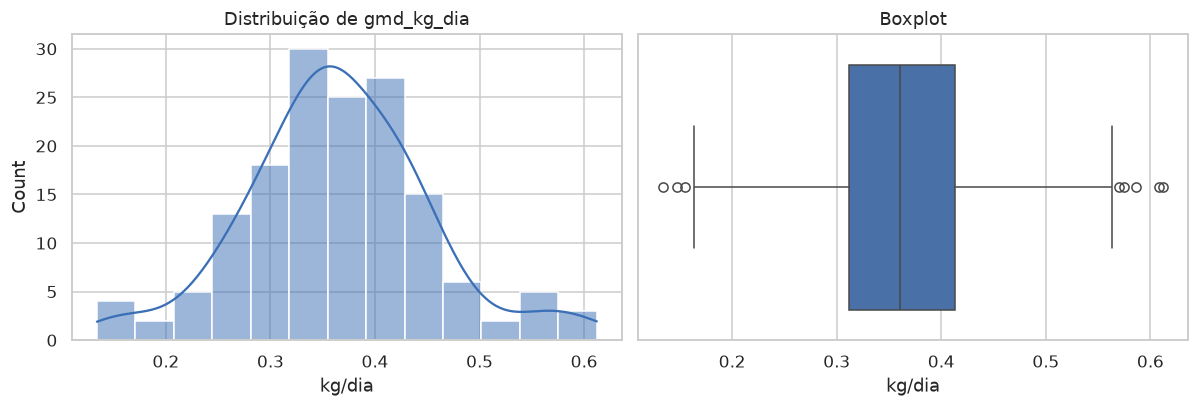

In [4]:
print(df[TARGET].describe().round(3).to_string())
print(f"skewness: {df[TARGET].skew():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(df[TARGET], kde=True, ax=ax[0], color="#3b6fb6")
ax[0].set_title(f"Distribuição de {TARGET}"); ax[0].set_xlabel("kg/dia")
sns.boxplot(x=df[TARGET], ax=ax[1], color="#3b6fb6")
ax[1].set_title("Boxplot"); ax[1].set_xlabel("kg/dia")
plt.tight_layout(); plt.show()

## 5. Preditores — variância e constantes

Com **uma única propriedade**, várias variáveis de manejo não variam.

In [5]:
nun = df[predictors].nunique().sort_values()
consts = nun[nun == 1].index.tolist()
print("CONSTANTES (sem variância -> sairiam do modelo):")
for c in consts: print(f"   {c} = {df[c].iloc[0]}")
print("\nCom variância:", [c for c in predictors if c not in consts])
nun.to_frame("nunique")

CONSTANTES (sem variância -> sairiam do modelo):
   proporcao_bos_indicus_pct = 75
   sexo_macho = 0
   frequencia_suplementacao_dias_semana = 7
   rotacao_piquete = 1

Com variância: ['peso_entrada_kg', 'dias_permanencia', 'media_suplemento_kg_dia', 'pb_suplemento_pct', 'media_proteina_bruta_forragem_pct', 'numero_eventos_transporte', 'temperatura_media_c', 'precipitacao_acumulada_mm', 'proporcao_ciclo_seca']


,nunique
proporcao_bos_indicus_pct,1
sexo_macho,1
frequencia_suplementacao_dias_semana,1
rotacao_piquete,1
numero_eventos_transporte,2
media_proteina_bruta_forragem_pct,2
pb_suplemento_pct,3
temperatura_media_c,49
dias_permanencia,52
proporcao_ciclo_seca,52


## 6. Distribuições dos preditores contínuos

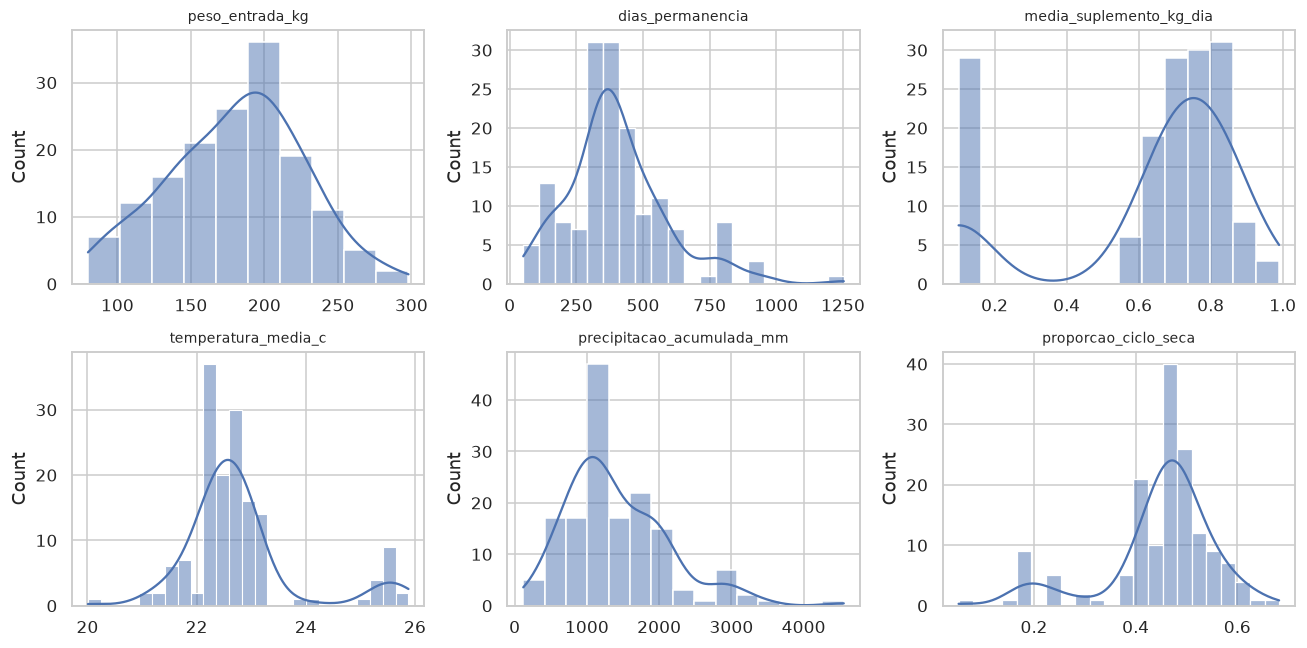

In [6]:
cont = [c for c in predictors if df[c].nunique() > 6]
n = len(cont); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3 * nrow))
axes = np.array(axes).reshape(-1)
for i, c in enumerate(cont):
    sns.histplot(df[c], kde=True, ax=axes[i]); axes[i].set_title(c, fontsize=9); axes[i].set_xlabel("")
for j in range(n, len(axes)): axes[j].axis("off")
plt.tight_layout(); plt.show()

## 7. Correlação (Pearson) com o alvo

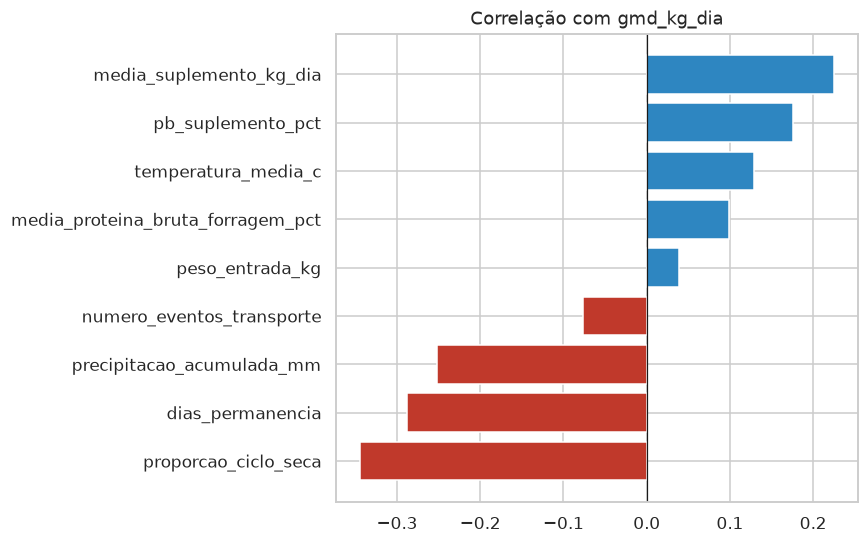

proporcao_ciclo_seca                -0.345
dias_permanencia                    -0.288
precipitacao_acumulada_mm           -0.252
numero_eventos_transporte           -0.076
peso_entrada_kg                      0.039
media_proteina_bruta_forragem_pct    0.099
temperatura_media_c                  0.128
pb_suplemento_pct                    0.175
media_suplemento_kg_dia              0.225
Name: gmd_kg_dia, dtype: float64

In [7]:
varia = [c for c in predictors if df[c].nunique() > 1]
corr_t = df[varia + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, 0.45 * len(corr_t) + 1))
colors = ["#c0392b" if v < 0 else "#2e86c1" for v in corr_t.values]
ax.barh(corr_t.index, corr_t.values, color=colors); ax.axvline(0, color="k", lw=.8)
ax.set_title(f"Correlação com {TARGET}"); plt.tight_layout(); plt.show()
corr_t.round(3)

## 8. Matriz de correlação e multicolinearidade

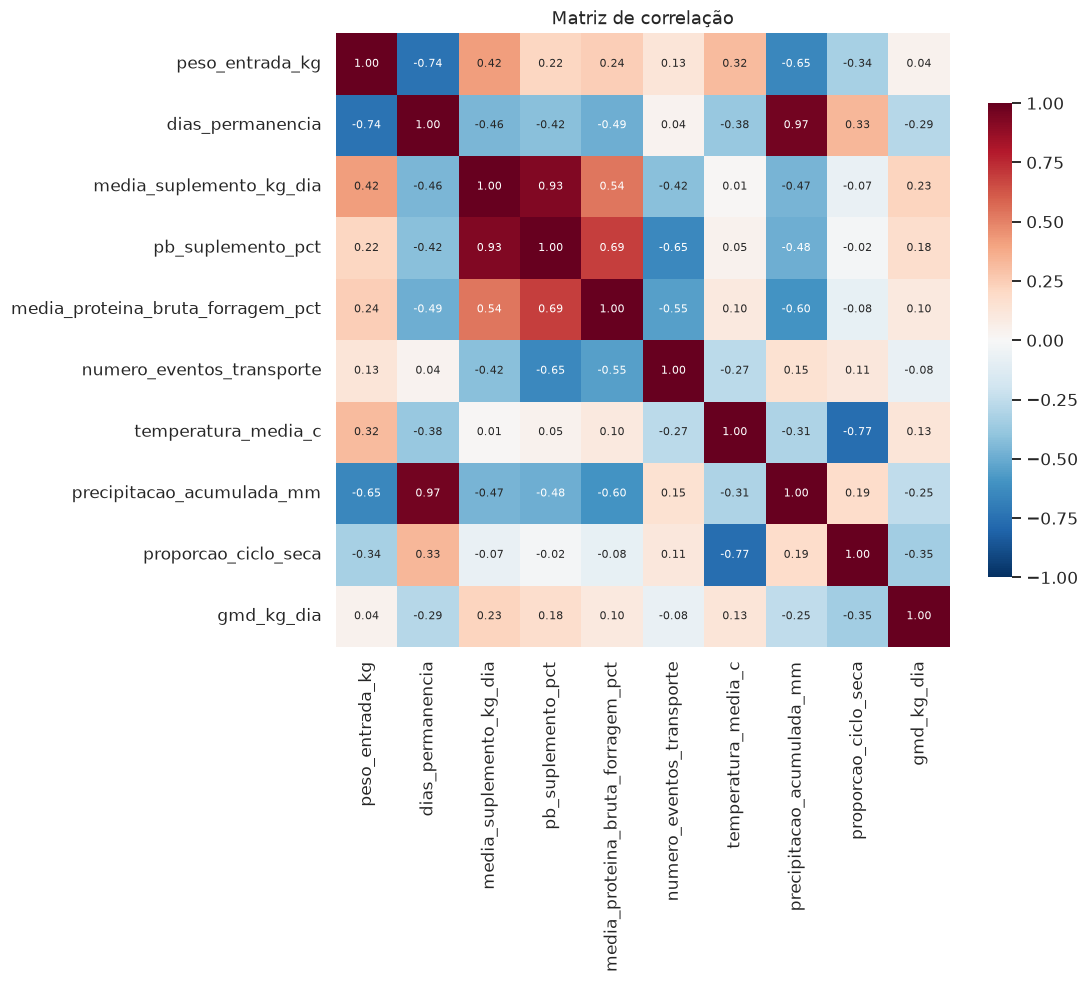

Pares multicolineares |r| > 0.8: [('dias_permanencia', 'precipitacao_acumulada_mm', np.float64(0.965)), ('media_suplemento_kg_dia', 'pb_suplemento_pct', np.float64(0.929))]


In [8]:
cm = df[varia + [TARGET]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, annot_kws={"size": 7}, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Matriz de correlação"); plt.show()

absm = df[varia].corr().abs()
pairs = [(a, b, round(absm.loc[a, b], 3)) for i, a in enumerate(varia)
         for b in varia[i+1:] if absm.loc[a, b] > 0.8]
print("Pares multicolineares |r| > 0.8:", pairs)

## 9. GMD por tipo de suplemento

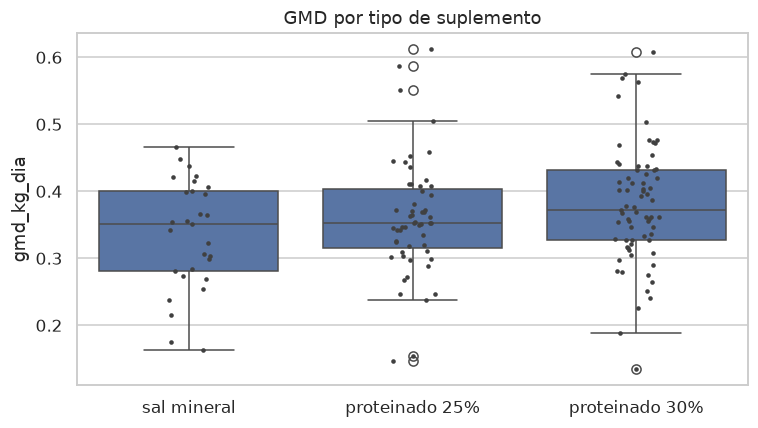

,count,mean,std
_suplemento,,,
proteinado 25%,55,0.360,0.087
proteinado 30%,71,0.379,0.089
sal mineral,29,0.336,0.081


In [9]:
df["_suplemento"] = np.where(df.pb_suplemento_pct == 0, "sal mineral",
                             "proteinado " + df.pb_suplemento_pct.astype(str) + "%")
order = df.groupby("_suplemento")[TARGET].mean().sort_values().index
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="_suplemento", y=TARGET, order=order, ax=ax)
sns.stripplot(data=df, x="_suplemento", y=TARGET, order=order, color=".25", size=3, ax=ax)
ax.set_title("GMD por tipo de suplemento"); ax.set_xlabel("")
plt.tight_layout(); plt.show()
df.groupby("_suplemento")[TARGET].agg(["count", "mean", "std"]).round(3)

## 10. Notas para a modelagem

- **1 propriedade (Elvis, 155 animais).** 5 preditores **constantes** (`sexo_macho`, `proporcao_bos_indicus_pct`, `frequencia_suplementacao_dias_semana`, `media_proteina_bruta_forragem_pct`, `rotacao_piquete`) — sairão do modelo; podem voltar a variar com a 2ª fazenda.
- **Alvo** quase simétrico (skew ~0.2) — sem necessidade urgente de transformação.
- **Correlações agronomicamente coerentes:** proporção de seca (−) e suplementação (+).
- **Multicolinearidade a tratar:** `dias_permanencia`×`precipitacao_acumulada_mm` (~0.97) e `media_suplemento_kg_dia`×`pb_suplemento_pct` (~0.93) — considerar remover uma de cada (integridade do SHAP).
- **Vazamento:** `peso_saida_kg` nunca entra nos preditores.